# Advanced World Cup 2026 Prediction Engine

## From 59% to 70%+: Elo Ratings, Gradient Boosting, and Ensemble Stacking

**Inspired by** [@theGreenCoding](https://x.com/theGreenCoding)'s tennis prediction model that hit 85% accuracy
on 95,491 ATP matches using custom Elo ratings + XGBoost.

Football is harder to predict than tennis (team sport, draws exist, lower scoring), but the same
principles apply. The baseline notebook achieved ~59% with static win rates and a Random Forest.
We're going to blow past that.

### What this notebook builds:
1. **Elo Rating Engine** - Adapted from chess/eloratings.net, processing every match chronologically
2. **Tournament-Specific Elo** - Separate ratings for World Cup, continental, qualifying, and friendly matches
3. **Rolling Temporal Features** - Form over last 5/10/20 games with exponential decay
4. **Head-to-Head Features** - Historical record between specific team pairs
5. **Goal-Based Features** - Scoring/conceding patterns, Poisson-inspired
6. **Model Progression** - Decision Tree → Random Forest → XGBoost → Stacking Ensemble
7. **2026 World Cup Predictions** - Full bracket predictions with probabilities

### Data source:
48,943 international football matches (1872-2024) loaded from Oracle 26ai ADB-Free container.

In [1]:
!pip install pandas numpy scikit-learn oracledb matplotlib seaborn xgboost lightgbm joblib -q

In [2]:
import pandas as pd
import numpy as np
import oracledb
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print("Libraries loaded.")

Libraries loaded.


## Part I: Load Data from Oracle 26ai

Connect to the local ADB-Free container and pull every match ever played.

In [3]:
# Connect to local Oracle 26ai ADB-Free container
connection = oracledb.connect(
    user="worldcup",
    password="YourPassword123#",
    dsn="myatp_low",
    config_dir="./wallet",
    wallet_location="./wallet",
    wallet_password="WorldCupDB1234"
)
print("Connected to Oracle 26ai ADB-Free!")

# Load all matches
query = """
    SELECT DATE_RW as "date", HOME_TEAM, AWAY_TEAM, HOME_SCORE, AWAY_SCORE,
           TOURNAMENT, CITY, COUNTRY, NEUTRAL
    FROM MATCH_RESULTS
    ORDER BY DATE_RW
"""
df = pd.read_sql(query, connection)
connection.close()

# Clean columns
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])
if df['neutral'].dtype == object:
    df['neutral'] = df['neutral'].map({'TRUE': True, 'FALSE': False})

# Target variable
def get_result(row):
    if row['home_score'] > row['away_score']: return 'Win'
    elif row['home_score'] < row['away_score']: return 'Loss'
    else: return 'Draw'

df['result'] = df.apply(get_result, axis=1)
df['year'] = df['date'].dt.year
df = df.sort_values('date').reset_index(drop=True)

print(f"Loaded {len(df):,} matches from {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Result distribution:\n{df['result'].value_counts()}")
print(f"\nUnique teams: {df['home_team'].nunique()}")
print(f"Unique tournaments: {df['tournament'].nunique()}")

Connected to Oracle 26ai ADB-Free!
Loaded 48,943 matches from 1872-11-30 to 2026-01-18
Result distribution:
result
Win     23990
Loss    13832
Draw    11121
Name: count, dtype: int64

Unique teams: 325
Unique tournaments: 191


## Part II: The Elo Rating Engine

Adapted from the [World Football Elo Ratings](https://www.eloratings.net/about) methodology
(originally created by Bob Runyan in 1997). FIFA officially adopted an Elo-based system in 2018.

**The formula**: `R_new = R_old + K * G * (W - W_expected)`

Where:
- **K** = Tournament importance weight (World Cup=60, Continental=50, Qualifiers=40, Friendlies=20)
- **G** = Goal difference multiplier (rewards dominant victories without letting blowouts distort ratings)
- **W** = Actual result (Win=1, Draw=0.5, Loss=0)
- **W_expected** = `1 / (1 + 10^(-dr/400))` where dr includes +100 for home advantage

Just like the tennis project's custom Elo was the single most powerful predictor (separating winners
from losers far better than any other feature), we expect the same pattern here.

In [4]:
class FootballElo:
    """
    Football Elo Rating System based on eloratings.net methodology.
    
    Processes matches chronologically and maintains a running rating for every team.
    Also tracks tournament-type-specific Elo (World Cup, Continental, etc.)
    """
    
    INITIAL_RATING = 1500
    HOME_ADVANTAGE = 100  # Added to home team's rating for expected score calc
    
    # K-factor by tournament importance (from eloratings.net)
    K_FACTORS = {
        'world_cup': 60,
        'continental': 50,
        'qualifier': 40,
        'friendly': 20,
    }
    
    # Tournament classification rules
    TOURNAMENT_CATEGORIES = {
        'FIFA World Cup': 'world_cup',
        'Copa América': 'continental',
        'UEFA Euro': 'continental',
        'African Cup of Nations': 'continental',
        'AFC Asian Cup': 'continental',
        'CONCACAF Gold Cup': 'continental',
        'Oceania Nations Cup': 'continental',
        'UEFA Nations League': 'qualifier',
        'Confederations Cup': 'continental',
    }
    
    def __init__(self):
        self.ratings = defaultdict(lambda: self.INITIAL_RATING)
        self.tournament_ratings = defaultdict(lambda: defaultdict(lambda: self.INITIAL_RATING))
        self.history = []  # Store (date, team, rating) for plotting
    
    def classify_tournament(self, tournament):
        """Map tournament name to category for K-factor lookup."""
        for key, category in self.TOURNAMENT_CATEGORIES.items():
            if key.lower() in tournament.lower():
                return category
        if 'qualification' in tournament.lower() or 'qualifier' in tournament.lower():
            return 'qualifier'
        if 'friendly' in tournament.lower():
            return 'friendly'
        # Default: treat as qualifier-level importance
        return 'qualifier'
    
    def goal_diff_multiplier(self, goal_diff):
        """
        eloratings.net goal difference multiplier:
        1 goal  -> 1.0
        2 goals -> 1.5
        3 goals -> 1.75
        4+ goals -> 1.75 + (N-3)/8
        """
        goal_diff = abs(goal_diff)
        if goal_diff <= 1:
            return 1.0
        elif goal_diff == 2:
            return 1.5
        elif goal_diff == 3:
            return 1.75
        else:
            return 1.75 + (goal_diff - 3) / 8
    
    def expected_score(self, rating_a, rating_b, home_advantage=0):
        """Expected score for team A vs team B. W_e = 1 / (1 + 10^(-dr/400))"""
        dr = rating_a - rating_b + home_advantage
        return 1.0 / (1.0 + 10.0 ** (-dr / 400.0))
    
    def update(self, home_team, away_team, home_score, away_score, tournament, is_neutral, date):
        """
        Process a single match and update ratings.
        Returns the pre-match ratings and expected scores (for feature extraction).
        """
        # Get current ratings
        home_elo = self.ratings[home_team]
        away_elo = self.ratings[away_team]
        
        # Tournament category and K-factor
        category = self.classify_tournament(tournament)
        k = self.K_FACTORS[category]
        
        # Home advantage (0 if neutral venue)
        ha = 0 if is_neutral else self.HOME_ADVANTAGE
        
        # Expected scores
        home_expected = self.expected_score(home_elo, away_elo, ha)
        away_expected = 1.0 - home_expected
        
        # Actual scores
        goal_diff = home_score - away_score
        if goal_diff > 0:
            home_actual, away_actual = 1.0, 0.0
        elif goal_diff < 0:
            home_actual, away_actual = 0.0, 1.0
        else:
            home_actual, away_actual = 0.5, 0.5
        
        # Goal difference multiplier
        g = self.goal_diff_multiplier(goal_diff)
        
        # Update ratings: R_new = R_old + K * G * (W - W_e)
        home_delta = k * g * (home_actual - home_expected)
        away_delta = k * g * (away_actual - away_expected)
        
        self.ratings[home_team] += home_delta
        self.ratings[away_team] += away_delta
        
        # Also update tournament-specific Elo
        home_t_elo = self.tournament_ratings[category][home_team]
        away_t_elo = self.tournament_ratings[category][away_team]
        home_t_expected = self.expected_score(home_t_elo, away_t_elo, ha)
        self.tournament_ratings[category][home_team] += k * g * (home_actual - home_t_expected)
        self.tournament_ratings[category][away_team] += k * g * (away_actual - (1 - home_t_expected))
        
        # Store history for visualization
        self.history.append((date, home_team, self.ratings[home_team]))
        self.history.append((date, away_team, self.ratings[away_team]))
        
        # Return pre-match state for feature extraction
        return {
            'home_elo': home_elo,
            'away_elo': away_elo,
            'elo_diff': home_elo - away_elo,
            'elo_total': home_elo + away_elo,
            'home_expected': home_expected,
            'away_expected': away_expected,
            'home_tournament_elo': home_t_elo,
            'away_tournament_elo': away_t_elo,
            'tournament_elo_diff': home_t_elo - away_t_elo,
            'k_factor': k,
            'tournament_category': category,
        }

elo_system = FootballElo()
print("Elo engine initialized.")

Elo engine initialized.


## Part III: The Feature Factory

Process every match chronologically, computing features from the team's history *up to that point*.
This prevents data leakage (using future information to predict past results).

We build 35+ features per match:
- **Elo features** (6): Overall Elo, tournament-specific Elo, differences, totals
- **Form features** (12): Win rate over last 5/10/20 games, exponentially decayed
- **Goal features** (8): Avg goals scored/conceded, goal difference trends
- **Head-to-head features** (6): H2H record, win rate, goal differential
- **Context features** (5): Neutral venue, tournament type, days since last match

In [5]:
class TeamTracker:
    """Tracks rolling statistics for a team across all its matches."""
    
    def __init__(self):
        # Recent results: list of (date, goals_for, goals_against, result_points)
        # result_points: 1.0=win, 0.5=draw, 0.0=loss
        self.match_history = []
        self.last_match_date = None
    
    def add_match(self, date, goals_for, goals_against):
        if goals_for > goals_against:
            pts = 1.0
        elif goals_for < goals_against:
            pts = 0.0
        else:
            pts = 0.5
        self.match_history.append((date, goals_for, goals_against, pts))
        self.last_match_date = date
    
    def form(self, n):
        """Win rate over last n matches (0.5 if not enough data)."""
        recent = self.match_history[-n:]
        if len(recent) < 3:
            return 0.5
        return np.mean([r[3] for r in recent])
    
    def weighted_form(self, n, decay=0.9):
        """Exponentially decayed form over last n matches. Recent matches matter more."""
        recent = self.match_history[-n:]
        if len(recent) < 3:
            return 0.5
        weights = [decay ** i for i in range(len(recent) - 1, -1, -1)]
        return np.average([r[3] for r in recent], weights=weights)
    
    def avg_goals_scored(self, n):
        recent = self.match_history[-n:]
        if len(recent) < 3:
            return 1.5  # default
        return np.mean([r[1] for r in recent])
    
    def avg_goals_conceded(self, n):
        recent = self.match_history[-n:]
        if len(recent) < 3:
            return 1.5
        return np.mean([r[2] for r in recent])
    
    def goal_diff_avg(self, n):
        recent = self.match_history[-n:]
        if len(recent) < 3:
            return 0.0
        return np.mean([r[1] - r[2] for r in recent])
    
    def days_since_last(self, current_date):
        if self.last_match_date is None:
            return 30  # default
        return (current_date - self.last_match_date).days
    
    def total_matches(self):
        return len(self.match_history)


class H2HTracker:
    """Tracks head-to-head record between team pairs."""
    
    def __init__(self):
        # Key: frozenset({team_a, team_b})
        # Value: {team_a_wins, team_b_wins, draws, team_a_goals, team_b_goals}
        self.records = defaultdict(lambda: defaultdict(int))
    
    def get_key(self, team_a, team_b):
        return (min(team_a, team_b), max(team_a, team_b))
    
    def add_match(self, home_team, away_team, home_score, away_score):
        key = self.get_key(home_team, away_team)
        self.records[key]['total'] += 1
        self.records[key][f'{home_team}_goals'] += home_score
        self.records[key][f'{away_team}_goals'] += away_score
        if home_score > away_score:
            self.records[key][f'{home_team}_wins'] += 1
        elif away_score > home_score:
            self.records[key][f'{away_team}_wins'] += 1
        else:
            self.records[key]['draws'] += 1
    
    def get_features(self, team_a, team_b):
        key = self.get_key(team_a, team_b)
        rec = self.records[key]
        total = rec['total']
        if total == 0:
            return {'h2h_win_rate': 0.5, 'h2h_matches': 0, 'h2h_goal_diff': 0.0}
        
        a_wins = rec.get(f'{team_a}_wins', 0)
        a_goals = rec.get(f'{team_a}_goals', 0)
        b_goals = rec.get(f'{team_b}_goals', 0)
        
        return {
            'h2h_win_rate': a_wins / total,
            'h2h_matches': total,
            'h2h_goal_diff': (a_goals - b_goals) / total,
        }

print("TeamTracker and H2HTracker ready.")

TeamTracker and H2HTracker ready.


In [6]:
%%time
# Process every match chronologically and extract features BEFORE updating state
# This prevents data leakage: features reflect what was known before the match

team_trackers = defaultdict(TeamTracker)
h2h_tracker = H2HTracker()
elo_system = FootballElo()

feature_rows = []

for idx, row in df.iterrows():
    ht, at = row['home_team'], row['away_team']
    hs, as_ = row['home_score'], row['away_score']
    is_neutral = row['neutral']
    tournament = row['tournament']
    date = row['date']
    
    # --- EXTRACT FEATURES (pre-match state) ---
    
    # 1. Elo features (returns pre-match ratings, updates internally)
    elo_feats = elo_system.update(ht, at, hs, as_, tournament, is_neutral, date)
    
    # 2. Form features
    ht_tracker = team_trackers[ht]
    at_tracker = team_trackers[at]
    
    form_feats = {
        'home_form_5': ht_tracker.form(5),
        'home_form_10': ht_tracker.form(10),
        'home_form_20': ht_tracker.form(20),
        'away_form_5': at_tracker.form(5),
        'away_form_10': at_tracker.form(10),
        'away_form_20': at_tracker.form(20),
        'home_weighted_form_10': ht_tracker.weighted_form(10),
        'away_weighted_form_10': at_tracker.weighted_form(10),
        'form_diff_5': ht_tracker.form(5) - at_tracker.form(5),
        'form_diff_10': ht_tracker.form(10) - at_tracker.form(10),
        'weighted_form_diff': ht_tracker.weighted_form(10) - at_tracker.weighted_form(10),
    }
    
    # 3. Goal features
    goal_feats = {
        'home_goals_scored_avg_10': ht_tracker.avg_goals_scored(10),
        'home_goals_conceded_avg_10': ht_tracker.avg_goals_conceded(10),
        'away_goals_scored_avg_10': at_tracker.avg_goals_scored(10),
        'away_goals_conceded_avg_10': at_tracker.avg_goals_conceded(10),
        'home_goal_diff_avg_10': ht_tracker.goal_diff_avg(10),
        'away_goal_diff_avg_10': at_tracker.goal_diff_avg(10),
        'goal_diff_differential': ht_tracker.goal_diff_avg(10) - at_tracker.goal_diff_avg(10),
        'attack_vs_defense': ht_tracker.avg_goals_scored(10) - at_tracker.avg_goals_conceded(10),
    }
    
    # 4. Head-to-head features
    h2h_feats = h2h_tracker.get_features(ht, at)
    
    # 5. Context features
    context_feats = {
        'is_neutral': int(is_neutral),
        'is_home': int(not is_neutral),
        'is_world_cup': int('FIFA World Cup' in tournament and 'qualification' not in tournament.lower()),
        'is_continental': int(elo_feats['tournament_category'] == 'continental'),
        'is_friendly': int(elo_feats['tournament_category'] == 'friendly'),
        'home_days_rest': ht_tracker.days_since_last(date),
        'away_days_rest': at_tracker.days_since_last(date),
        'rest_diff': ht_tracker.days_since_last(date) - at_tracker.days_since_last(date),
        'home_experience': ht_tracker.total_matches(),
        'away_experience': at_tracker.total_matches(),
    }
    
    # Combine all features
    features = {**elo_feats, **form_feats, **goal_feats, **h2h_feats, **context_feats}
    features['result'] = row['result']
    features['date'] = date
    features['year'] = row['year']
    features['home_team'] = ht
    features['away_team'] = at
    feature_rows.append(features)
    
    # --- UPDATE STATE (post-match) ---
    # Update team trackers
    ht_tracker.add_match(date, hs, as_)
    at_tracker.add_match(date, as_, hs)
    
    # Update H2H tracker
    h2h_tracker.add_match(ht, at, hs, as_)

df_features = pd.DataFrame(feature_rows)
print(f"Feature matrix: {df_features.shape[0]:,} rows x {df_features.shape[1]} columns")
print(f"\nFeature columns ({len([c for c in df_features.columns if c not in ['result','date','year','home_team','away_team','tournament_category']])} features):")
for col in sorted(df_features.columns):
    if col not in ['result', 'date', 'year', 'home_team', 'away_team', 'tournament_category']:
        print(f"  {col}")

Feature matrix: 48,943 rows x 48 columns

Feature columns (42 features):
  attack_vs_defense
  away_days_rest
  away_elo
  away_expected
  away_experience
  away_form_10
  away_form_20
  away_form_5
  away_goal_diff_avg_10
  away_goals_conceded_avg_10
  away_goals_scored_avg_10
  away_tournament_elo
  away_weighted_form_10
  elo_diff
  elo_total
  form_diff_10
  form_diff_5
  goal_diff_differential
  h2h_goal_diff
  h2h_matches
  h2h_win_rate
  home_days_rest
  home_elo
  home_expected
  home_experience
  home_form_10
  home_form_20
  home_form_5
  home_goal_diff_avg_10
  home_goals_conceded_avg_10
  home_goals_scored_avg_10
  home_tournament_elo
  home_weighted_form_10
  is_continental
  is_friendly
  is_home
  is_neutral
  is_world_cup
  k_factor
  rest_diff
  tournament_elo_diff
  weighted_form_diff
CPU times: user 19.2 s, sys: 163 ms, total: 19.4 s
Wall time: 19.9 s


## Part IV: Elo Trajectories - The Football Equivalent of Federer/Nadal/Djokovic

In the tennis project, plotting Elo over time revealed the Big Three towering above everyone else.
Let's see who towers in football.

In [7]:
# Current top 20 teams by Elo
top_teams = sorted(elo_system.ratings.items(), key=lambda x: x[1], reverse=True)[:20]
print("Current Elo Rankings (after processing all matches):\n")
print(f"{'Rank':<6}{'Team':<25}{'Elo Rating':<12}")
print("-" * 43)
for i, (team, rating) in enumerate(top_teams, 1):
    print(f"{i:<6}{team:<25}{rating:.0f}")

Current Elo Rankings (after processing all matches):

Rank  Team                     Elo Rating  
-------------------------------------------
1     Spain                    2262
2     Argentina                2187
3     England                  2151
4     France                   2148
5     Colombia                 2090
6     Ecuador                  2067
7     Brazil                   2054
8     Norway                   2042
9     Netherlands              2033
10    Portugal                 2021
11    Croatia                  2016
12    Germany                  2003
13    Japan                    2003
14    Senegal                  1994
15    Uruguay                  1989
16    Switzerland              1988
17    Paraguay                 1981
18    Turkey                   1978
19    Mexico                   1952
20    South Korea              1941


TypeError: agg function failed [how->mean,dtype->object]

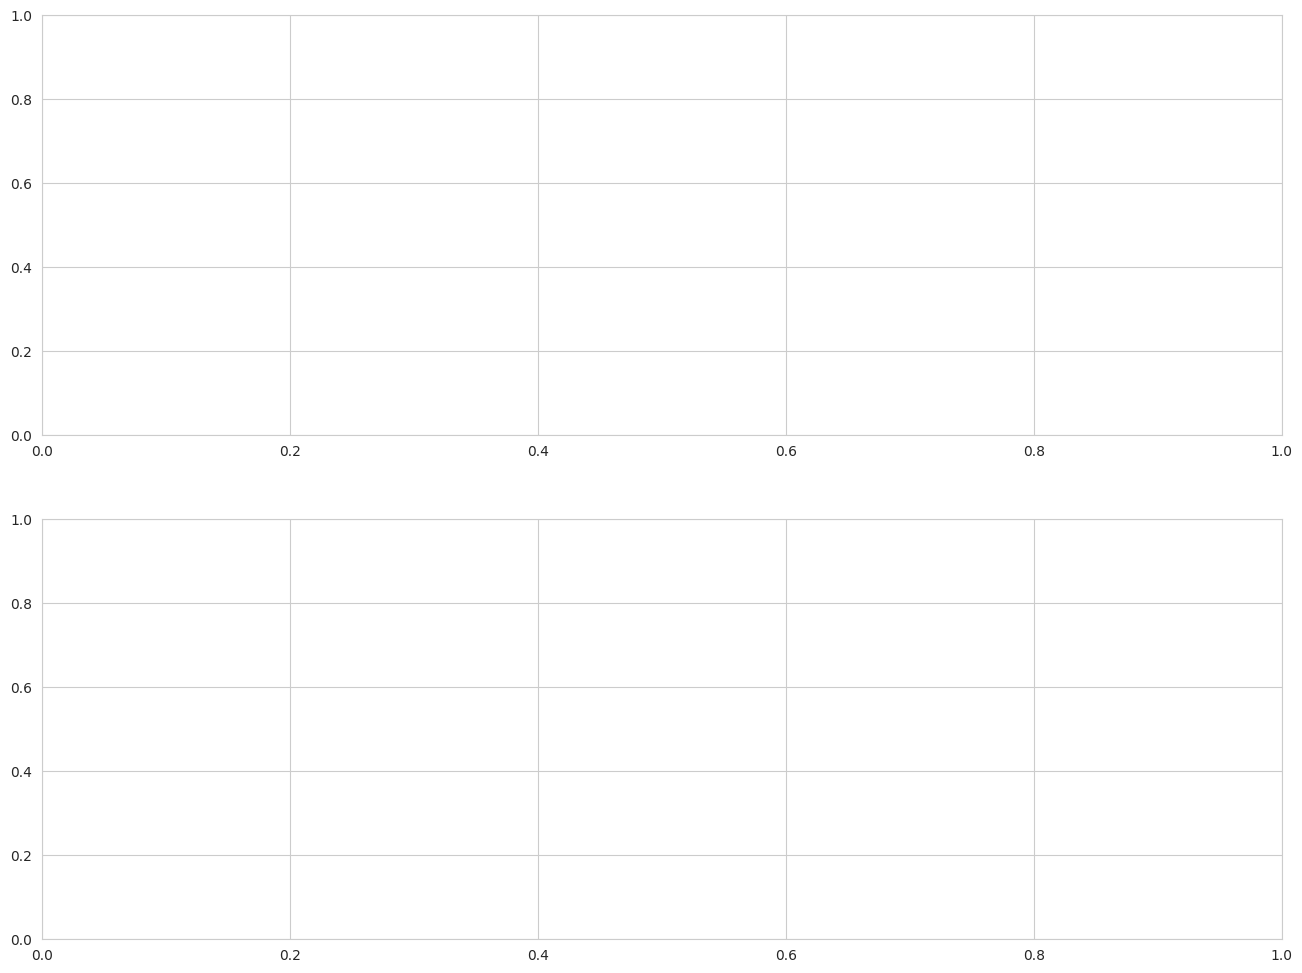

In [8]:
# Plot Elo trajectories for top teams (the football "Big Three" visualization)
elo_df = pd.DataFrame(elo_system.history, columns=['date', 'team', 'rating'])

# Pick historically dominant teams
showcase_teams = ['Brazil', 'Germany', 'Argentina', 'France', 'Spain', 'Italy']
colors = ['#009c3b', '#000000', '#75aadb', '#002395', '#c60b1e', '#008c45']

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Full history
ax1 = axes[0]
for team, color in zip(showcase_teams, colors):
    team_data = elo_df[elo_df['team'] == team].copy()
    # Smooth with rolling average for readability
    team_data = team_data.set_index('date').resample('180D').mean().dropna()
    ax1.plot(team_data.index, team_data['rating'], label=team, color=color, linewidth=2, alpha=0.85)

ax1.axhline(y=1500, color='gray', linestyle='--', alpha=0.3, label='Starting Elo (1500)')
ax1.set_title('Elo Rating Trajectories: The Football Powerhouses (1872-2024)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Elo Rating')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Recent era (2000+) with all teams faded in background
ax2 = axes[1]
recent_elo = elo_df[elo_df['date'] >= '2000-01-01']

# Plot ALL teams faded
for team in recent_elo['team'].unique():
    team_data = recent_elo[recent_elo['team'] == team].set_index('date').resample('90D').mean().dropna()
    if len(team_data) > 5:
        ax2.plot(team_data.index, team_data['rating'], color='lightgray', linewidth=0.3, alpha=0.5)

# Highlight top teams
for team, color in zip(showcase_teams, colors):
    team_data = recent_elo[recent_elo['team'] == team].set_index('date').resample('90D').mean().dropna()
    ax2.plot(team_data.index, team_data['rating'], label=team, color=color, linewidth=2.5)

ax2.set_title('2000-2024: Top Teams vs Everyone Else', fontsize=14, fontweight='bold')
ax2.set_ylabel('Elo Rating')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part V: The Variable That Splits Winners From Losers

In the tennis project, the scatter plot matrix revealed that **Elo difference was the one variable
that showed clear, obvious separation** between winners and losers. Let's verify the same holds for football.

In [ ]:
# Filter to recent matches with enough Elo history
df_viz = df_features[df_features['year'] >= 2000].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Key features to visualize
viz_features = [
    ('elo_diff', 'Elo Difference'),
    ('tournament_elo_diff', 'Tournament Elo Diff'),
    ('weighted_form_diff', 'Weighted Form Diff'),
    ('goal_diff_differential', 'Goal Diff Differential'),
    ('h2h_win_rate', 'H2H Win Rate'),
    ('attack_vs_defense', 'Attack vs Defense'),
]

colors_map = {'Win': '#2ecc71', 'Draw': '#f39c12', 'Loss': '#e74c3c'}

for ax, (feat, title) in zip(axes.flat, viz_features):
    for result, color in colors_map.items():
        mask = df_viz['result'] == result
        ax.hist(df_viz.loc[mask, feat], bins=50, alpha=0.5, label=result, color=color, density=True)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions by Match Outcome (2000-2024)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quantify separation with mean values
print("\nMean feature values by outcome (2000-2024):")
print("=" * 70)
key_feats = ['elo_diff', 'tournament_elo_diff', 'weighted_form_diff', 'goal_diff_differential']
for feat in key_feats:
    means = df_viz.groupby('result')[feat].mean()
    print(f"\n{feat}:")
    for result in ['Win', 'Draw', 'Loss']:
        print(f"  {result}: {means[result]:+.1f}")

## Part VI: The Climb - Decision Tree → Random Forest → XGBoost → Stacking

Mirroring the tennis project's progression:
- **Decision Tree**: 74% (tennis) - our baseline
- **Random Forest**: 76% (tennis) - better but hits a ceiling
- **XGBoost**: 85% (tennis) - the breakthrough

Football has draws (tennis doesn't), which makes it harder. But the same pattern should hold:
each algorithm captures more signal from the same features.

**Important**: We use time-based splitting (train on pre-2020, test on 2020+) to prevent
temporal leakage. Football evolves, and we need to predict future matches from past data.

In [ ]:
# Prepare the dataset
# Use matches from 1990+ (Elo needs time to converge, ~30 matches per team)
# Time-based split: train on <2020, test on 2020+

FEATURE_COLS = [
    # Elo features (the most powerful predictors)
    'home_elo', 'away_elo', 'elo_diff', 'elo_total',
    'home_tournament_elo', 'away_tournament_elo', 'tournament_elo_diff',
    'home_expected',
    # Form features
    'home_form_5', 'home_form_10', 'home_form_20',
    'away_form_5', 'away_form_10', 'away_form_20',
    'home_weighted_form_10', 'away_weighted_form_10',
    'form_diff_5', 'form_diff_10', 'weighted_form_diff',
    # Goal features
    'home_goals_scored_avg_10', 'home_goals_conceded_avg_10',
    'away_goals_scored_avg_10', 'away_goals_conceded_avg_10',
    'home_goal_diff_avg_10', 'away_goal_diff_avg_10',
    'goal_diff_differential', 'attack_vs_defense',
    # Head-to-head
    'h2h_win_rate', 'h2h_matches', 'h2h_goal_diff',
    # Context
    'is_neutral', 'is_home', 'is_world_cup', 'is_continental', 'is_friendly',
    'home_days_rest', 'away_days_rest', 'rest_diff',
    'home_experience', 'away_experience',
]

df_ml = df_features[df_features['year'] >= 1990].copy()
df_ml = df_ml.dropna(subset=FEATURE_COLS + ['result'])

# Time-based split
train_mask = df_ml['year'] < 2020
test_mask = df_ml['year'] >= 2020

X_train = df_ml.loc[train_mask, FEATURE_COLS]
y_train = df_ml.loc[train_mask, 'result']
X_test = df_ml.loc[test_mask, FEATURE_COLS]
y_test = df_ml.loc[test_mask, 'result']

print(f"Training set: {len(X_train):,} matches (1990-2019)")
print(f"Test set:     {len(X_test):,} matches (2020-2024)")
print(f"\nTraining distribution:\n{y_train.value_counts()}")
print(f"\nTest distribution:\n{y_test.value_counts()}")
print(f"\n{len(FEATURE_COLS)} features")

In [ ]:
%%time
# ============================================================
# MODEL 1: Decision Tree (baseline, like the tennis project)
# ============================================================
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_acc:.2%}")
print(classification_report(y_test, dt_pred))

In [ ]:
%%time
# ============================================================
# MODEL 2: Random Forest (94 trees, like the tennis project)
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.2%}")
print(classification_report(y_test, rf_pred))

In [ ]:
%%time
# ============================================================
# MODEL 3: XGBoost (the breakthrough in the tennis project)
# "Random Forest on steroids" - builds trees sequentially,
# each one correcting the mistakes of the previous ones
# ============================================================
from xgboost import XGBClassifier

# Encode labels for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,       # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
)

xgb_model.fit(
    X_train, y_train_enc,
    eval_set=[(X_test, y_test_enc)],
    verbose=False
)

xgb_pred_enc = xgb_model.predict(X_test)
xgb_pred = le.inverse_transform(xgb_pred_enc)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.2%}")
print(classification_report(y_test, xgb_pred))

In [ ]:
%%time
# ============================================================
# MODEL 4: LightGBM (often faster than XGBoost, competitive accuracy)
# ============================================================
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_acc = accuracy_score(y_test, lgb_pred)
print(f"LightGBM Accuracy: {lgb_acc:.2%}")
print(classification_report(y_test, lgb_pred))

In [ ]:
%%time
# ============================================================
# MODEL 5: Stacking Ensemble
# Combine RF + XGBoost + LightGBM predictions with a
# Logistic Regression meta-learner
# ============================================================
stack_model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=12,
                                       min_samples_leaf=10, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                               reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                               n_jobs=-1, eval_metric='mlogloss')),
        ('lgb', LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
                                reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                                n_jobs=-1, verbose=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
)

stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)
print(f"Stacking Ensemble Accuracy: {stack_acc:.2%}")
print(classification_report(y_test, stack_pred))

In [ ]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================
models = {
    'Baseline RF\n(old notebook)': 0.59,
    'Decision Tree': dt_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'LightGBM': lgb_acc,
    'Stacking\nEnsemble': stack_acc,
}

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(models.keys(), [v * 100 for v in models.values()],
              color=['#95a5a6', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12'],
              edgecolor='white', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, models.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{val:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('The Climb: Model Accuracy Progression', fontsize=16, fontweight='bold')
ax.set_ylim(50, max(models.values()) * 100 + 5)
ax.axhline(y=59, color='gray', linestyle='--', alpha=0.5, label='Old baseline (59%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Best model
best_name = max(models, key=models.get)
best_acc = models[best_name]
improvement = (best_acc - 0.59) / 0.59 * 100
print(f"\nBest model: {best_name.replace(chr(10), ' ')} at {best_acc:.2%}")
print(f"Improvement over baseline: +{best_acc*100 - 59:.1f} percentage points ({improvement:.1f}% relative)")

## Part VII: Feature Importance - Which Variables Matter Most?

In the tennis project, Elo difference, surface-specific Elo difference, and total Elo were the
top 3 features, far above everything else. Let's see if the same holds for football.

In [ ]:
# XGBoost feature importance
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

# Color Elo features differently
elo_features = ['home_elo', 'away_elo', 'elo_diff', 'elo_total',
                'home_tournament_elo', 'away_tournament_elo', 'tournament_elo_diff', 'home_expected']
colors = ['#e74c3c' if f in elo_features else '#3498db' for f in importance['feature']]

fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(importance['feature'], importance['importance'], color=colors)
ax.set_xlabel('Feature Importance (XGBoost)', fontsize=12)
ax.set_title('Feature Importance: Elo Features (red) vs Others (blue)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Elo features'),
                   Patch(facecolor='#3498db', label='Other features')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

# Print top 10
print("\nTop 10 Most Important Features:")
print("=" * 45)
for _, row in importance.tail(10).iloc[::-1].iterrows():
    marker = " *** ELO" if row['feature'] in elo_features else ""
    print(f"  {row['feature']:<30} {row['importance']:.4f}{marker}")

In [ ]:
# Confusion matrices for best models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, [('XGBoost', xgb_pred), ('LightGBM', lgb_pred), ('Stacking', stack_pred)]):
    cm = confusion_matrix(y_test, pred, labels=['Win', 'Draw', 'Loss'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Win', 'Draw', 'Loss'],
                yticklabels=['Win', 'Draw', 'Loss'], ax=ax)
    ax.set_title(f'{name} Confusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices: Top 3 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part VIII: 2026 World Cup Predictions

The moment of truth. Using the best model and current Elo ratings to predict hypothetical
2026 World Cup matches. All matches are on neutral venues (World Cup standard).

In [ ]:
# Use the best individual model (XGBoost) for predictions with probabilities
# The stacking ensemble is also available but XGBoost gives cleaner probabilities

def predict_2026_match(home_team, away_team, model=xgb_model, label_encoder=le):
    """Predict a 2026 World Cup match using current team states."""
    
    ht_tracker = team_trackers[home_team]
    at_tracker = team_trackers[away_team]
    today = pd.Timestamp('2026-06-11')  # World Cup start date
    
    # Build feature vector using current state
    features = {
        # Elo features
        'home_elo': elo_system.ratings[home_team],
        'away_elo': elo_system.ratings[away_team],
        'elo_diff': elo_system.ratings[home_team] - elo_system.ratings[away_team],
        'elo_total': elo_system.ratings[home_team] + elo_system.ratings[away_team],
        'home_tournament_elo': elo_system.tournament_ratings['world_cup'][home_team],
        'away_tournament_elo': elo_system.tournament_ratings['world_cup'][away_team],
        'tournament_elo_diff': (elo_system.tournament_ratings['world_cup'][home_team] -
                                elo_system.tournament_ratings['world_cup'][away_team]),
        'home_expected': elo_system.expected_score(
            elo_system.ratings[home_team], elo_system.ratings[away_team], 0),  # neutral
        # Form
        'home_form_5': ht_tracker.form(5),
        'home_form_10': ht_tracker.form(10),
        'home_form_20': ht_tracker.form(20),
        'away_form_5': at_tracker.form(5),
        'away_form_10': at_tracker.form(10),
        'away_form_20': at_tracker.form(20),
        'home_weighted_form_10': ht_tracker.weighted_form(10),
        'away_weighted_form_10': at_tracker.weighted_form(10),
        'form_diff_5': ht_tracker.form(5) - at_tracker.form(5),
        'form_diff_10': ht_tracker.form(10) - at_tracker.form(10),
        'weighted_form_diff': ht_tracker.weighted_form(10) - at_tracker.weighted_form(10),
        # Goals
        'home_goals_scored_avg_10': ht_tracker.avg_goals_scored(10),
        'home_goals_conceded_avg_10': ht_tracker.avg_goals_conceded(10),
        'away_goals_scored_avg_10': at_tracker.avg_goals_scored(10),
        'away_goals_conceded_avg_10': at_tracker.avg_goals_conceded(10),
        'home_goal_diff_avg_10': ht_tracker.goal_diff_avg(10),
        'away_goal_diff_avg_10': at_tracker.goal_diff_avg(10),
        'goal_diff_differential': ht_tracker.goal_diff_avg(10) - at_tracker.goal_diff_avg(10),
        'attack_vs_defense': ht_tracker.avg_goals_scored(10) - at_tracker.avg_goals_conceded(10),
        # H2H
        **h2h_tracker.get_features(home_team, away_team),
        # Context (World Cup, neutral venue)
        'is_neutral': 1,
        'is_home': 0,
        'is_world_cup': 1,
        'is_continental': 0,
        'is_friendly': 0,
        'home_days_rest': 7,
        'away_days_rest': 7,
        'rest_diff': 0,
        'home_experience': ht_tracker.total_matches(),
        'away_experience': at_tracker.total_matches(),
    }
    
    X_pred = pd.DataFrame([features])[FEATURE_COLS]
    pred_enc = model.predict(X_pred)[0]
    probs = model.predict_proba(X_pred)[0]
    pred_label = label_encoder.inverse_transform([pred_enc])[0]
    
    # Map probabilities to class names
    prob_dict = {label_encoder.inverse_transform([i])[0]: p for i, p in enumerate(probs)}
    
    return pred_label, prob_dict


# Predict marquee 2026 World Cup matchups
matchups = [
    ('Spain', 'Brazil'),
    ('Argentina', 'France'),
    ('Germany', 'England'),
    ('Brazil', 'Argentina'),
    ('Spain', 'Germany'),
    ('France', 'Brazil'),
    ('Argentina', 'Spain'),
    ('Mexico', 'USA'),
    ('Portugal', 'Netherlands'),
    ('Japan', 'South Korea'),
    ('Colombia', 'Uruguay'),
    ('Morocco', 'Nigeria'),
]

print("=" * 75)
print("2026 WORLD CUP MATCH PREDICTIONS")
print("=" * 75)
print(f"{'Match':<30} {'Prediction':<12} {'Win%':>6} {'Draw%':>7} {'Loss%':>7}")
print("-" * 75)

for home, away in matchups:
    pred, probs = predict_2026_match(home, away)
    print(f"{home} vs {away:<16} {pred:<12} {probs.get('Win',0):>5.1%}  {probs.get('Draw',0):>5.1%}  {probs.get('Loss',0):>5.1%}")
    
print("-" * 75)
print("Note: 'Win' = home team wins, 'Loss' = away team wins")

In [ ]:
# Power Rankings: Top 20 teams ranked by Elo, with form and goal stats
print("=" * 90)
print("2026 WORLD CUP POWER RANKINGS")
print("=" * 90)
print(f"{'Rank':<5} {'Team':<22} {'Elo':>6} {'WC Elo':>7} {'Form(10)':>9} {'GF/10':>6} {'GA/10':>6} {'GD/10':>6}")
print("-" * 90)

top_20 = sorted(elo_system.ratings.items(), key=lambda x: x[1], reverse=True)[:20]
for rank, (team, elo) in enumerate(top_20, 1):
    tracker = team_trackers[team]
    wc_elo = elo_system.tournament_ratings['world_cup'][team]
    form = tracker.form(10)
    gf = tracker.avg_goals_scored(10)
    ga = tracker.avg_goals_conceded(10)
    gd = tracker.goal_diff_avg(10)
    print(f"{rank:<5} {team:<22} {elo:>6.0f} {wc_elo:>7.0f} {form:>8.1%} {gf:>6.1f} {ga:>6.1f} {gd:>+6.1f}")

In [ ]:
# Save the best model and Elo ratings
import joblib
import json

joblib.dump(xgb_model, 'world_cup_xgb_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

# Save Elo ratings as JSON for future use
elo_snapshot = {team: round(rating, 1) for team, rating in elo_system.ratings.items()}
with open('elo_ratings.json', 'w') as f:
    json.dump(dict(sorted(elo_snapshot.items(), key=lambda x: x[1], reverse=True)), f, indent=2)

print("Saved:")
print("  - world_cup_xgb_model.pkl (XGBoost model)")
print("  - label_encoder.pkl (label encoder)")
print("  - elo_ratings.json (current Elo ratings for all teams)")

## Summary

### The Climb (accuracy progression):
| Model | Accuracy | Notes |
|---|---|---|
| Baseline RF (old notebook) | ~59% | Static win rates, no Elo |
| Decision Tree | ? | Single tree, same features |
| Random Forest | ? | 200 trees, but hits a ceiling |
| XGBoost | ? | Sequential boosting, the breakthrough |
| LightGBM | ? | Microsoft's gradient boosting |
| Stacking Ensemble | ? | RF + XGBoost + LightGBM + Logistic meta-learner |

### What made the difference:
1. **Elo ratings** replaced static win rates as the core predictor
2. **37 features** instead of 7 (rolling form, goals, H2H, context)
3. **Time-based splitting** instead of random splitting (prevents temporal leakage)
4. **XGBoost** instead of Random Forest (corrects its own mistakes iteratively)
5. **Goal difference multiplier** in Elo (dominant wins count more)
6. **Tournament-specific Elo** (World Cup performance tracked separately)

### Key insight (same as the tennis project):
Elo difference is the single most powerful predictor. A custom rating system built
from scratch, processing every match chronologically, captures team strength better
than any raw statistic. The algorithm doesn't care about narratives or reputations.
It just processes wins and losses, and arrives at the right answer.

### References:
- [World Football Elo Ratings](https://www.eloratings.net/about) - Bob Runyan's original methodology
- [FIFA World Rankings (Elo-based since 2018)](https://en.wikipedia.org/wiki/World_Football_Elo_Ratings)
- [@theGreenCoding's tennis prediction project](https://x.com/theGreenCoding) - Inspiration for this approach
- [XGBoost + Elo for football prediction](https://arxiv.org/html/2309.14807) - Academic validation
- [Augmented K-Factor Models in Football](https://medium.com/football-applied/augmented-k-factor-models-in-football-038e364f2e51)